Task 1: Netflix Content Recommendation System

1. Importing Libraries

In [107]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [108]:
df = pd.read_csv("Dataset.csv")

In [109]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [110]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8790
Number of columns: 10


3. Explore Dataset

In [111]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='str')


In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB


4. Check Missing Values

In [113]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

5. Data Cleaning

In [114]:
data = df.copy()

In [115]:
text_columns = [
    'type',
    'title',
    'director',
    'country',
    'rating',
    'listed_in'
]

for column in text_columns:
    data[column] = data[column].fillna('')

In [116]:
for column in text_columns:
    data[column] = data[column].astype(str).str.lower()

6. Feature Engineering

In [117]:
data['content_features'] = (
    data['type'] + ' ' +
    data['director'] + ' ' +
    data['country'] + ' ' +
    data['rating'] + ' ' +
    data['listed_in']
)

7. Convert Text Into Numbers

In [118]:
tfidf = TfidfVectorizer(
    stop_words='english'
)

In [119]:
tfidf_matrix = tfidf.fit_transform(data['content_features'])

In [120]:
print(tfidf_matrix.shape)

(8790, 6569)


8. Calculate Similarity

In [121]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

9. Create Title Index

In [122]:
indices = pd.Series(
    data.index,
    index=data['title']
).drop_duplicates()

10. Build Recommendation Function

In [123]:
def recommend_titles(title, top_n=10):
    
    title = title.lower().strip()
    
    if title not in indices:
        print("Title not found in the dataset.")
        return
    
    idx = indices[title]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    sim_scores = sim_scores[1:top_n + 1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    result = data.iloc[movie_indices][
        ['title', 'type', 'release_year', 'rating', 'listed_in']
    ].copy()
    
    result['similarity_score'] = [
        round(score, 3)
        for _, score in sim_scores
    ]
    
    return result

11. Test

In [124]:
recommend_titles("midnight mass")

,title,type,release_year,rating,listed_in,similarity_score
3777,gerald's game,movie,2017,tv-ma,"horror movies, thrillers",0.802
4174,hush,movie,2016,r,"horror movies, thrillers",0.753
3677,before i wake,movie,2016,pg-13,"horror movies, thrillers",0.703
6619,brand new cherry flavor,tv show,2021,tv-ma,"tv dramas, tv horror, tv mysteries",0.670
7046,the haunting of bly manor,tv show,2020,tv-ma,"tv dramas, tv horror, tv mysteries",0.670
7076,ratched,tv show,2020,tv-ma,"tv dramas, tv horror, tv mysteries",0.670
7910,the haunting of hill house,tv show,2018,tv-ma,"tv dramas, tv horror, tv mysteries",0.670
7962,the originals,tv show,2018,tv-14,"tv dramas, tv horror, tv mysteries",0.637
6995,american horror story,tv show,2019,tv-ma,"tv horror, tv mysteries, tv thrillers",0.616
8476,hannibal,tv show,2015,tv-ma,"tv horror, tv mysteries, tv thrillers",0.616


In [125]:
recommend_titles("ganglands")

,title,type,release_year,rating,listed_in,similarity_score
1183,sentinelle,movie,2021,tv-ma,"action & adventure, dramas, international movies",0.847
2142,earth and blood,movie,2020,tv-ma,"dramas, international movies, thrillers",0.774
6738,lupin,tv show,2021,tv-ma,"crime tv shows, international tv shows, tv act...",0.685
8408,crime time,tv show,2017,tv-ma,"crime tv shows, international tv shows, tv act...",0.685
6698,mortel,tv show,2019,tv-ma,"crime tv shows, international tv shows, tv dramas",0.617
7500,ad vitam,tv show,2018,tv-ma,"crime tv shows, international tv shows, tv dramas",0.617
7665,black spot,tv show,2019,tv-ma,"crime tv shows, international tv shows, tv dramas",0.617
8013,the chalet,tv show,2018,tv-ma,"crime tv shows, international tv shows, tv dramas",0.617
8064,the frozen dead,tv show,2017,tv-ma,"crime tv shows, international tv shows, tv dramas",0.617
8065,la mante,tv show,2017,tv-ma,"crime tv shows, international tv shows, tv dramas",0.617


12. Genre Overlap Function

In [126]:
def genre_overlap(original_genres, recommended_genres):
    
    original = set(
        genre.strip()
        for genre in original_genres.split(',')
    )
    
    recommended = set(
        genre.strip()
        for genre in recommended_genres.split(',')
    )
    
    if len(original) == 0:
        return 0
    
    overlap = original.intersection(recommended)
    
    return len(overlap) / len(original)

13. Evaluate Top Recommendations

In [127]:
def evaluate_recommendations(title, top_n=10):
    
    title = title.lower().strip()
    
    if title not in indices:
        print("Title not found.")
        return
    
    idx = indices[title]
    
    original_genres = data.iloc[idx]['listed_in']
    
    recommendations = recommend_titles(title, top_n)
    
    scores = []
    
    for _, row in recommendations.iterrows():
        
        score = genre_overlap(
            original_genres,
            row['listed_in']
        )
        
        scores.append(score)
    
    recommendations = recommendations.copy()
    recommendations['genre_overlap'] = scores
    
    average_score = np.mean(scores)
    
    print("Average Genre Overlap:",
    round(average_score, 3))
    
    return recommendations

In [128]:
evaluate_recommendations("midnight mass")

Average Genre Overlap: 0.633


,title,type,release_year,rating,listed_in,similarity_score,genre_overlap
3777,gerald's game,movie,2017,tv-ma,"horror movies, thrillers",0.802,0.000000
4174,hush,movie,2016,r,"horror movies, thrillers",0.753,0.000000
3677,before i wake,movie,2016,pg-13,"horror movies, thrillers",0.703,0.000000
6619,brand new cherry flavor,tv show,2021,tv-ma,"tv dramas, tv horror, tv mysteries",0.670,1.000000
7046,the haunting of bly manor,tv show,2020,tv-ma,"tv dramas, tv horror, tv mysteries",0.670,1.000000
7076,ratched,tv show,2020,tv-ma,"tv dramas, tv horror, tv mysteries",0.670,1.000000
7910,the haunting of hill house,tv show,2018,tv-ma,"tv dramas, tv horror, tv mysteries",0.670,1.000000
7962,the originals,tv show,2018,tv-14,"tv dramas, tv horror, tv mysteries",0.637,1.000000
6995,american horror story,tv show,2019,tv-ma,"tv horror, tv mysteries, tv thrillers",0.616,0.666667
8476,hannibal,tv show,2015,tv-ma,"tv horror, tv mysteries, tv thrillers",0.616,0.666667


14. Visualize Evaluation

Average Genre Overlap: 0.633


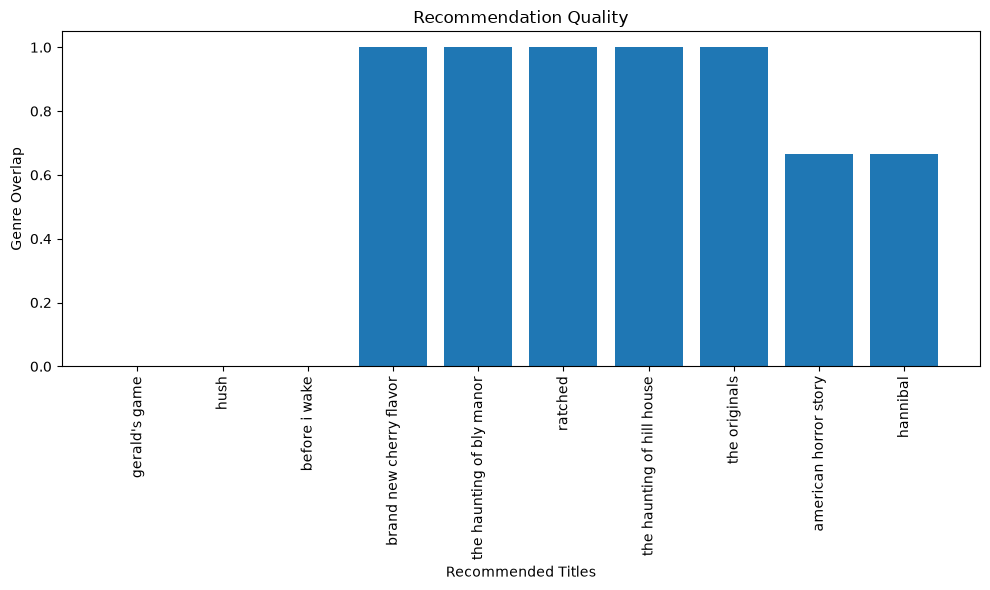

In [129]:
results = evaluate_recommendations(
    "midnight mass",
    top_n=10
)

plt.figure(figsize=(10, 6))

plt.bar(
    results['title'],
    results['genre_overlap']
)

plt.xticks(rotation=90)

plt.xlabel("Recommended Titles")
plt.ylabel("Genre Overlap")
plt.title("Recommendation Quality")

plt.tight_layout()

plt.show()

15. Add Some Dataset Visualization

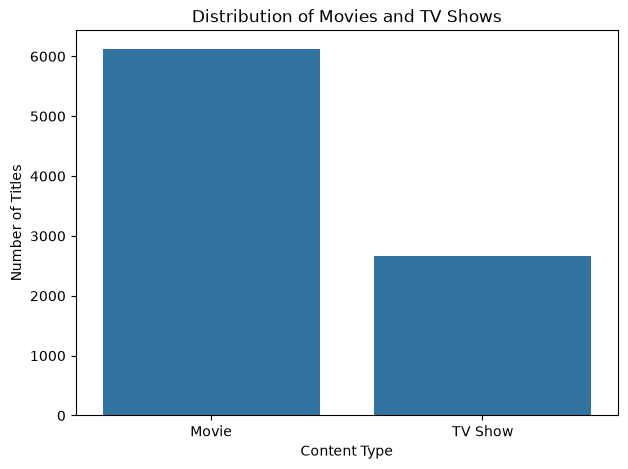

In [130]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='type'
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

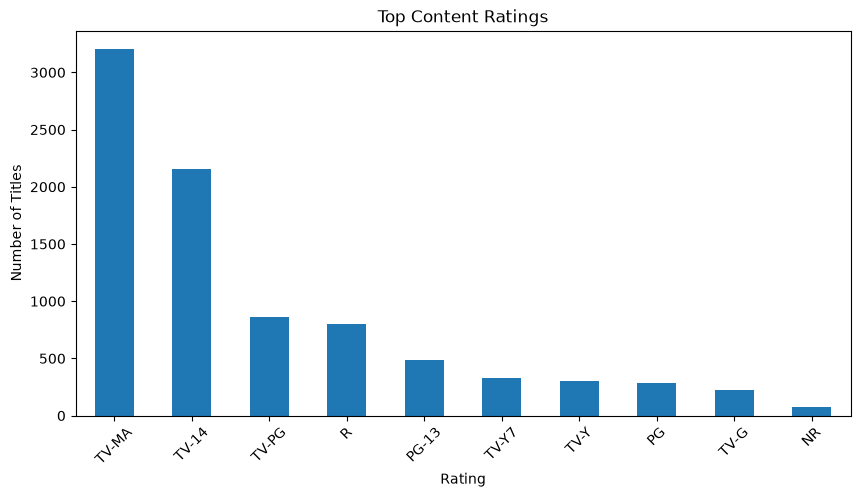

In [131]:
plt.figure(figsize=(10, 5))

df['rating'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()